# ModC Week 5 — Support Vector Machines

**Domain:** Marketing Conversion Propensity 
**Dataset:** Predict Conversion in Digital Marketing

SVM classifiers with linear, RBF, and polynomial kernels, compared against logistic regression for conversion prediction.

## 1. Imports and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

predict_conversion = load_dataset('Predict Conversion in Digital Marketing')

Predict Conversion in Digital Marketing loaded: digital_marketing_campaign_dataset.csv | shape=(8000, 20)


## 2. Preprocessing (same target as Week 4)

In [2]:

df = predict_conversion.copy()
target_col = pick_column(df, ['Conversion', 'Converted', 'conversion'])
if target_col is None:
    raise ValueError('Could not find binary conversion target in Predict Conversion in Digital Marketing.')

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.lower().map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
model_df = df.dropna(subset=[target_col]).copy()
for col in cat_cols:
    if col != target_col and model_df[col].nunique() <= 15:
        model_df = pd.concat([
            model_df.drop(columns=[col]),
            pd.get_dummies(model_df[col], prefix=col, drop_first=True)
        ], axis=1)

id_cols = [c for c in model_df.columns if c.lower().endswith('id')]
model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number]).fillna(model_df.median(numeric_only=True))
y = model_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Dropped ID columns:', id_cols)


Dropped ID columns: ['CustomerID']


## 3. Baseline Logistic Regression (Week 4 reference)

In [3]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

logit = LogisticRegression(max_iter=5000, C=1.0, random_state=42)
logit.fit(X_train_s, y_train)
logit_prob = logit.predict_proba(X_test_s)[:, 1]
logit_pred = logit.predict(X_test_s)

baseline = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, logit_pred),
    'F1': f1_score(y_test, logit_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, logit_prob),
}
print(baseline)


{'Model': 'Logistic Regression', 'Accuracy': 0.887, 'F1': 0.9390507011866235, 'ROC-AUC': 0.7697550295502678}


## 4. Linear, RBF, and Polynomial SVM

In [4]:

from sklearn.svm import SVC

svm_configs = {
    'Linear SVM': SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'RBF SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Poly SVM (deg=3)': SVC(kernel='poly', degree=3, C=1.0, gamma='scale', probability=True, random_state=42),
}

svm_results = []
trained = {}
for name, model in svm_configs.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    prob = model.predict_proba(X_test_s)[:, 1]
    trained[name] = model
    svm_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, prob),
    })

results_df = pd.DataFrame([baseline] + svm_results)
print(results_df)


                 Model  Accuracy        F1   ROC-AUC
0  Logistic Regression    0.8870  0.939051  0.769755
1           Linear SVM    0.8765  0.934186  0.668231
2              RBF SVM    0.8845  0.937887  0.764445
3     Poly SVM (deg=3)    0.8890  0.939935  0.747457


## 5. Hyperparameter Tuning — RBF SVM

In [5]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
}
rbf_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
rbf_grid.fit(X_train_s, y_train)
print('Best RBF params:', rbf_grid.best_params_)
print('Best CV ROC-AUC:', rbf_grid.best_score_)

best_rbf = rbf_grid.best_estimator_
rbf_pred = best_rbf.predict(X_test_s)
rbf_prob = best_rbf.predict_proba(X_test_s)[:, 1]


Best RBF params: {'C': 1, 'gamma': 0.01}
Best CV ROC-AUC: 0.7994765842488885


## 6. Kernel Trick — 2D Decision Boundaries

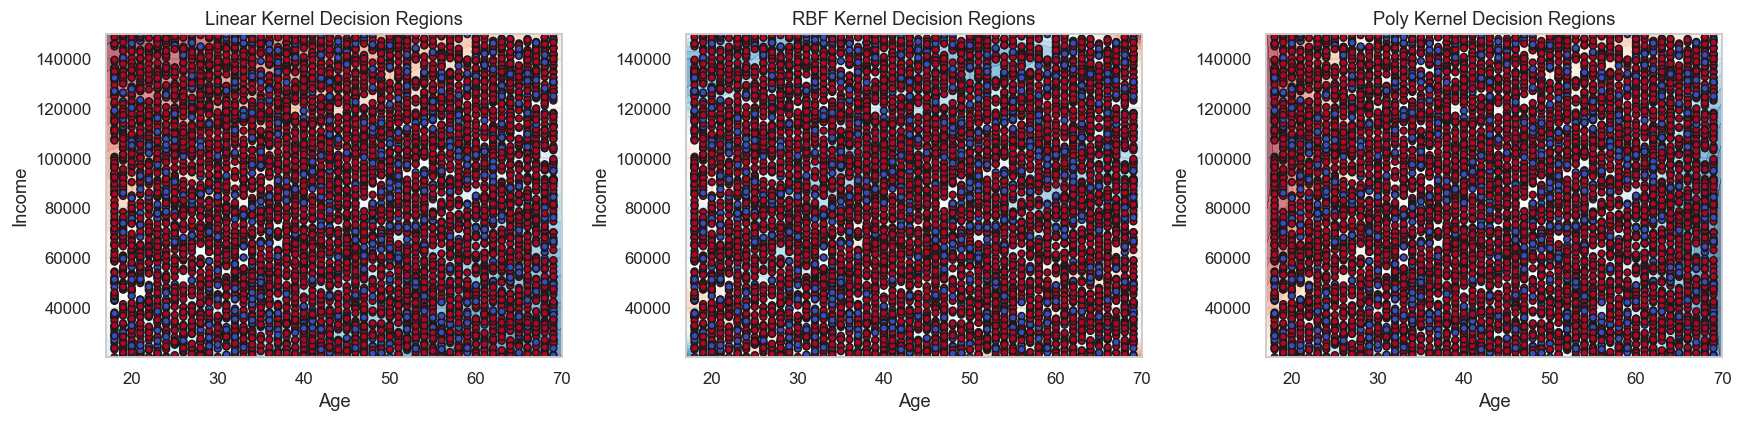

In [6]:

from sklearn.metrics import RocCurveDisplay

# Pick two informative numeric features for visualization
feat_a = pick_column(df, ['Time Spent', 'Time_Spent', 'Age', 'Page Views']) or X.columns[0]
feat_b = pick_column(df, ['Ad Click', 'Ad_Click', 'Page Views', 'Session']) or X.columns[1]
if feat_a == feat_b:
    feat_b = [c for c in X.columns if c != feat_a][0]

X2 = df[[feat_a, feat_b]].fillna(df[[feat_a, feat_b]].median()).values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)
X2_train = StandardScaler().fit_transform(X2_train)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 200),
    np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 200)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, kernel) in zip(axes, [('Linear', 'linear'), ('RBF', 'rbf'), ('Poly', 'poly')]):
    clf = SVC(kernel=kernel, C=1.0, gamma='scale', degree=3)
    clf.fit(X2_train, y2_train)
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = StandardScaler().fit(X2).transform(grid)
    Z = clf.decision_function(grid_scaled).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, alpha=0.6, cmap='RdBu')
    ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(f'{name} Kernel Decision Regions')
    ax.set_xlabel(feat_a)
    ax.set_ylabel(feat_b)
plt.tight_layout()
plt.show()


## 7. Results Comparison

                 Model  Accuracy        F1   ROC-AUC
0  Logistic Regression    0.8870  0.939051  0.769755
1           Linear SVM    0.8765  0.934186  0.668231
2              RBF SVM    0.8845  0.937887  0.764445
3     Poly SVM (deg=3)    0.8890  0.939935  0.747457
4      RBF SVM (tuned)    0.8765  0.934186  0.785925


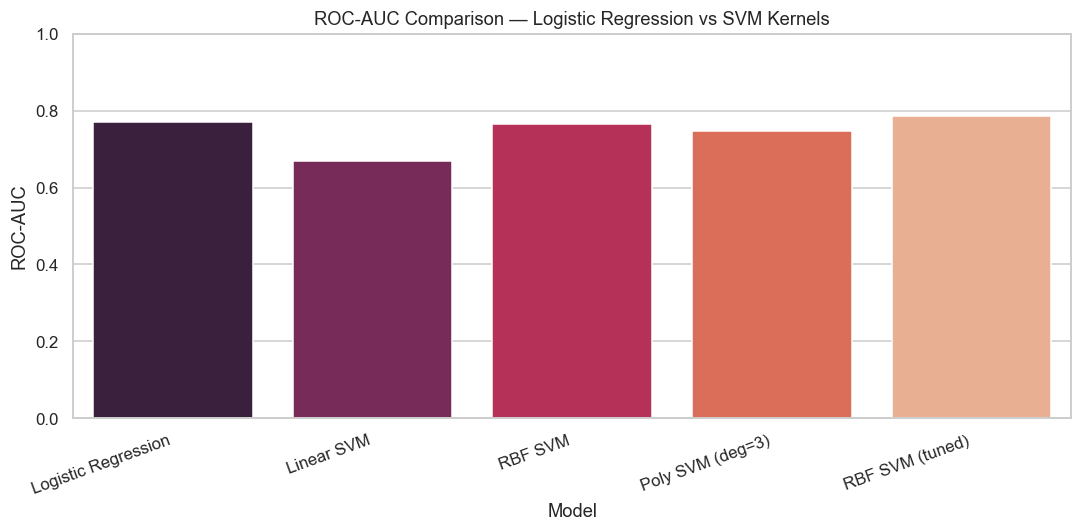

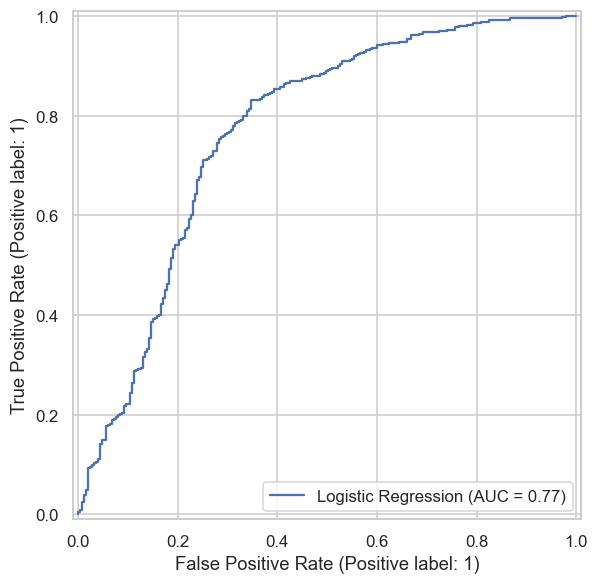

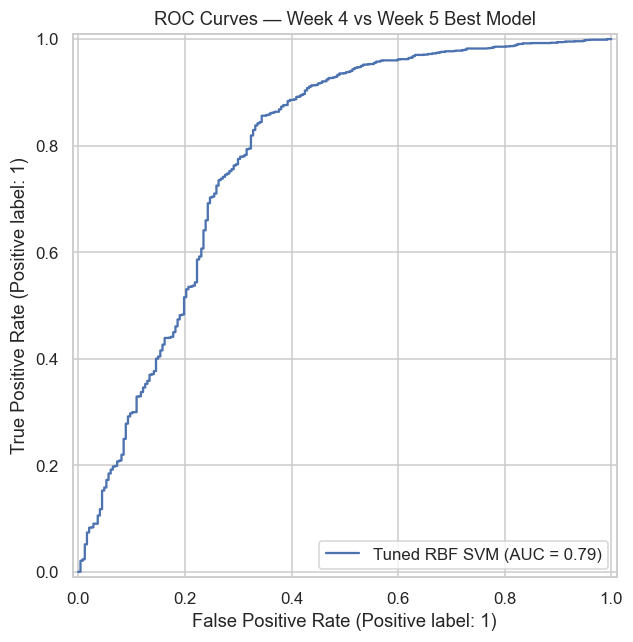

In [7]:

tuned_row = {
    'Model': 'RBF SVM (tuned)',
    'Accuracy': accuracy_score(y_test, rbf_pred),
    'F1': f1_score(y_test, rbf_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, rbf_prob),
}
final_results = pd.concat([results_df, pd.DataFrame([tuned_row])], ignore_index=True)
print(final_results)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=final_results, x='Model', y='ROC-AUC', palette='rocket', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('ROC-AUC Comparison — Logistic Regression vs SVM Kernels')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

from pathlib import Path
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / 'figure5.png', bbox_inches='tight', dpi=160)

plt.show()

RocCurveDisplay.from_predictions(y_test, logit_prob, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, rbf_prob, name='Tuned RBF SVM')
plt.title('ROC Curves — Week 4 vs Week 5 Best Model')
plt.tight_layout()
plt.show()


## 8. Conclusions

**Kernels:** Linear SVM assumes a linear decision boundary in feature space; RBF and polynomial kernels map inputs to higher-dimensional spaces (kernel trick) to capture non-linear engagement patterns.

**Regularization:** `C` controls the margin–misclassification tradeoff. Lower `C` widens the margin (more regularization); higher `C` fits training conversions more tightly and may overfit.

**Gamma (RBF):** Governs the influence radius of each support vector — large gamma can create complex boundaries and overfit sparse campaign segments.

**Comparison to logistic regression:** If tuned RBF SVM materially beats logistic ROC-AUC, non-linear interactions among behavioral features likely matter. If gains are small, logistic regression may be preferred for interpretability in marketing targeting.

**Deployment note:** SVMs scale poorly to very large datasets; for high-volume ad logs, logistic or linear SVM baselines remain strong production candidates.